# Testing mandelbrot-calculator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
from dataclasses import dataclass

from mandelbrot_calculator import (
    is_in_mandelbrot_set,
    MandelbrotSet,
)

Let's first test the function that determines whether a given point is in the Mandelbrot set, `is_in_mandelbrot_set(re, im, max_iter)`:

In [2]:
print(is_in_mandelbrot_set(0, 0.5, 100))

True


Next, let's test the class that allows the user to calculate the Mandelbrot set for a chosen grid size:

In [3]:
ms_1 = MandelbrotSet(5000)

Now, let's calculate whether points on a $1000\times 1000$ grid spanning $[-1, 1]\times [-1, 1]$ on the complex plane are in the Mandelbrot set:

In [4]:
re_min, re_max, im_min, im_max = -1, 1, -1, 1

grid = ms_1.make_grid_parallell(re_min, re_max, im_min, im_max, 1000)

What do you know, it looks how I hoped:

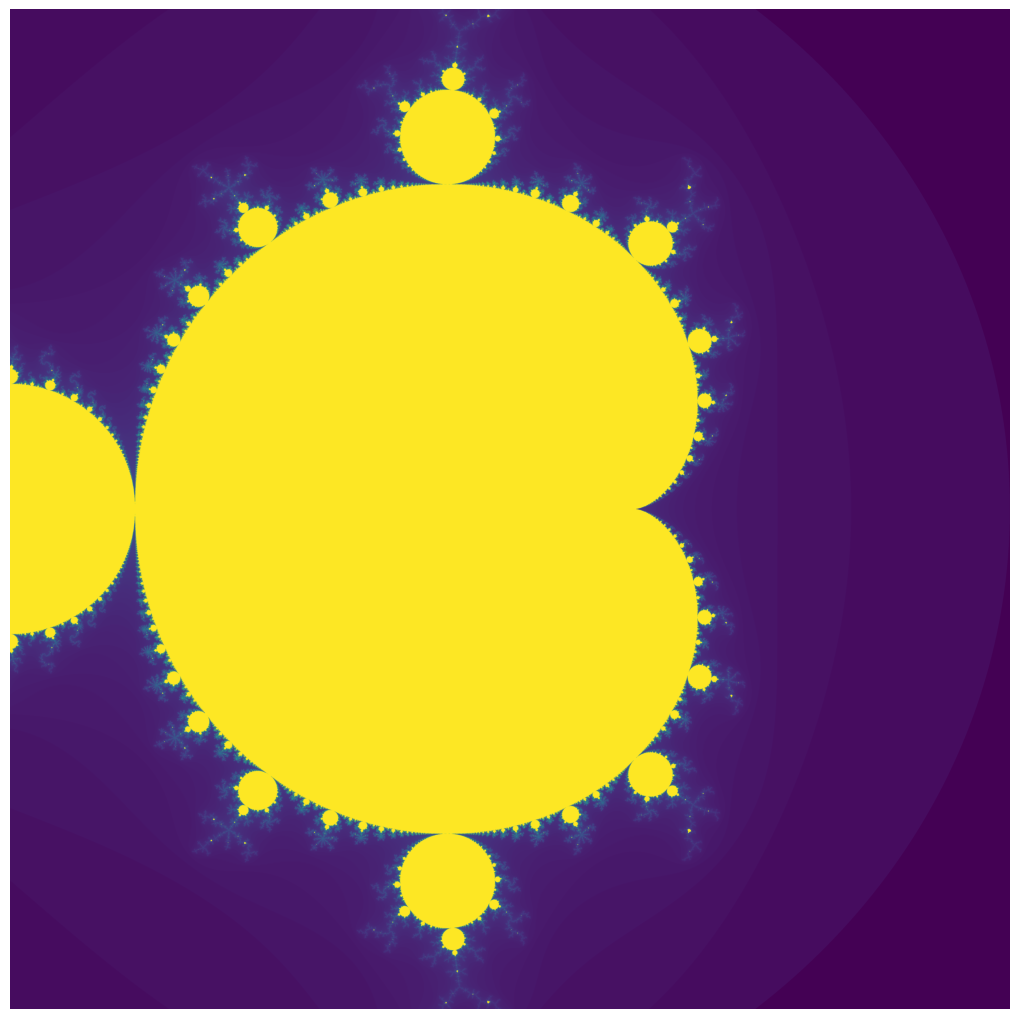

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(grid, extent=(re_min, re_max, im_min, im_max), norm=colors.PowerNorm(0.5))
ax.set_xticks(np.linspace(re_min, re_max, 5))
ax.set_yticks(np.linspace(im_min, im_max, 5))
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_visible(False)
plt.tight_layout(pad=0)
plt.show()

## Iterative zoom

Since the Mandelbrot is a fractal (i.e. it's pattern repeats itself as you zoom in), it's worthwhile making an iterative plot where we zoom into some point.

In [6]:
ms_2 = MandelbrotSet(2500)

Let's first make some tools that'll make the plotting easier, a dataclass to hold limits of the domain to be plotted and a function to add a plott:

In [7]:
@dataclass
class Limits:
    re_min: float
    re_max: float
    im_min: float
    im_max: float

def add_plot_to_ax(
        ax: plt.Axes,
        ms: MandelbrotSet,
        max_iter: int,
        limits: Limits,
        new_limits: Limits | None = None
    ) -> None:
    grid = ms.make_grid_parallell(limits.re_min, limits.re_max, limits.im_min, limits.im_max, max_iter)

    ax.imshow(grid, extent=(limits.re_min, limits.re_max, limits.im_min, limits.im_max), norm=colors.PowerNorm(0.8))
    ax.set_aspect('equal')
    ax.axis('off')

    if new_limits is not None:
        rect = Rectangle(
            (new_limits.re_min,new_limits.im_min),
            new_limits.re_max-new_limits.re_min,
            new_limits.im_max-new_limits.im_min,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

Next, let's use the tools above to zoom in to the point $(-0.743, 0.1)$:

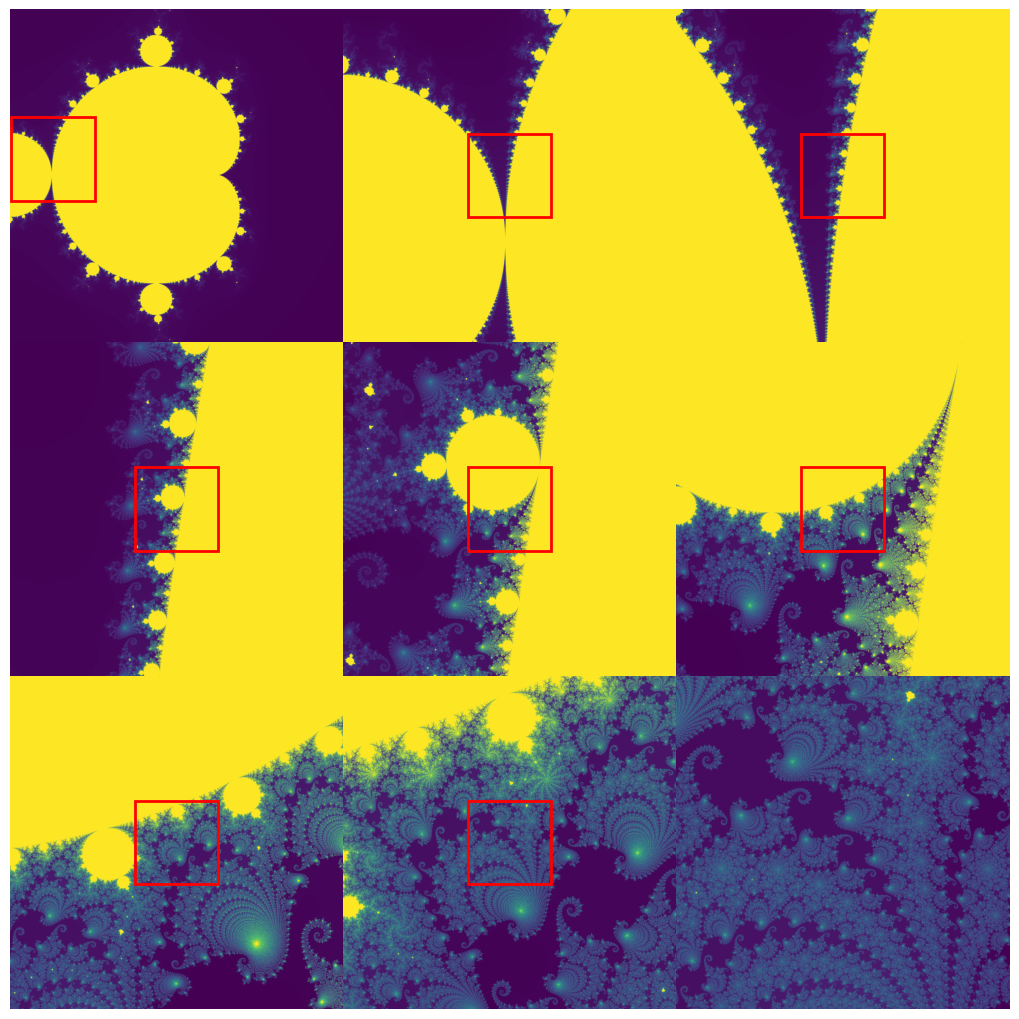

In [8]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
axs = axs.flatten()

zoom_into = (-0.743, 0.1)
limits = Limits(-1, 1, -1, 1)
new_limits = Limits(
    zoom_into[0]-0.25,
    zoom_into[0]+0.25,
    zoom_into[1]-0.25,
    zoom_into[1]+0.25
)

add_plot_to_ax(axs[0], ms_2, 1000, limits, new_limits)

for i, ax in enumerate(axs[1:-1]):
    limits = new_limits
    new_limits = Limits(
        (limits.re_min+limits.re_max)/2-(limits.re_max-limits.re_min)/8,
        (limits.re_min+limits.re_max)/2+(limits.re_max-limits.re_min)/8,
        (limits.im_min+limits.im_max)/2-(limits.im_max-limits.im_min)/8,
        (limits.im_min+limits.im_max)/2+(limits.im_max-limits.im_min)/8
    )
    add_plot_to_ax(ax, ms_2, 1000+200*(i+1)**2, limits, new_limits)

add_plot_to_ax(axs[-1], ms_2, 1000+200*8**2, new_limits)

fig.patch.set_visible(False)
plt.tight_layout(pad=0)
plt.show()